In [1]:
import numpy as np
import xarray as xr
# plottng
import cmocean as cmo
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import cmasher as cma
import pandas as pd

import cartopy.crs as ccrs  # Projections list
import cartopy.feature as cfeature

import scipy
import scipy.stats as stats
from scipy.stats import pearsonr

from statsmodels.tsa.stattools import ccf
from amocatlas import read

from process_data import MHT_selection, MHT_lat_selection, plot_hovmöller, plot_crosscorr, lowpass_filter

from statistics import acf_calc_plot, integral_time_scale, standard_error

ImportError: cannot import name 'acf_calc_plot' from 'statistics' (/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/statistics.py)

In [ ]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 16,
    'axes.labelsize'  : 14,
    # ticks
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,
    # legend
    'legend.fontsize' : 11,
    'legend.title_fontsize': 12,
    # colorbar
    'figure.titlesize': 18,
})

In [ ]:
ds = read.calafat2025()

lats = ds.LATITUDE.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'N' if lat > 0 else 'S'}" for lat in lats][1:]


MHT_dict = MHT_selection(ds, statistics=True, anomalies=True, time_mean=True, drop65=True)

lats = MHT_dict["lats"]
mht = MHT_dict["MHT"] # this is mean over posterior samples!
mht_stats = MHT_dict["MHT_statistics"] 
mht_mean = mht_stats["mean"]
mht_time_mean = mht_stats["time_mean"]
mht_all_mean = mht_time_mean.mean(dim="posterior_samples")

mht_std = mht_stats["std"]
mht_ci = mht_stats["ci"]

# mht_anom = MHT_dict["MHT_anom"]
# choose one lat: 
lat_sel = 5
MHT_lat = MHT_lat_selection(MHT_dict, lat=lat_sel, ci=90, anomalies=True)

mht_lat = MHT_lat["MHT_lat"]
mht_lat_stats = MHT_lat["MHT_lat_statistics"] 
mht_lat_mean = MHT_lat["MHT_lat_statistics"]["mean"]
mht_lat_time_mean = MHT_lat["MHT_lat_statistics"]["time_mean"]


seasonal_clim = mht_mean.groupby('TIME.month').mean(dim='TIME')  # shape: (12, lat)

# subtract it from each timestep
mht_anom = mht_mean.groupby('TIME.month') - seasonal_clim
mht_deseasonalized = mht_anom + mht_all_mean
mht_smooth = lowpass_filter(mht_deseasonalized)

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



In [ ]:
ds = mht_smooth

# for NAN checking

In [ ]:

# da = mht_smooth
# print(da.isnull().sum())
# print(f"NaN percentage: {da.isnull().mean() * 100:.2f}%")

# nan_any  = da.isnull().any(dim='TIME')   # True if ANY sample is NaN
# nan_all  = da.isnull().all(dim='TIME')   # True if ALL samples are NaN

# print("Inconsistent NaNs (some samples missing, not all):", 
#       bool((nan_any & ~nan_all).any()))
# # Visualize gaps

# nan_map = da.isnull()

# nan_map.plot(x='TIME', y='lat', cmap='viridis')
# # plt.xlim(right=pd.Timestamp("2005-01-01"))
# plt.title("NaN fraction across posterior samples")


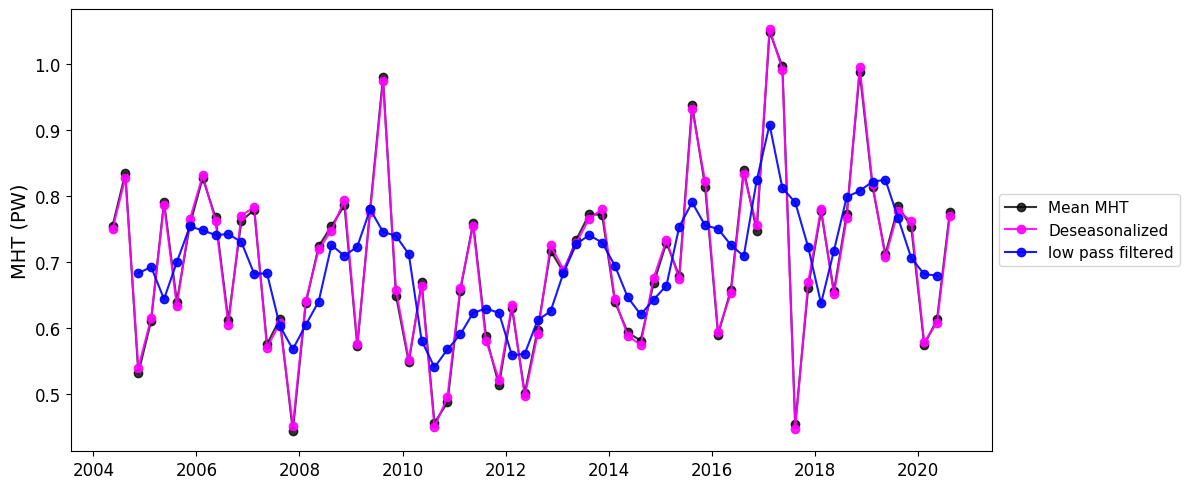

In [ ]:
mht_mean_lat = mht_mean.mean(dim="lat")
mht_deseasonalized_lat = mht_deseasonalized.mean(dim="lat")
mht_smooth_lat = mht_smooth.mean(dim="lat")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(mht_mean_lat.TIME, mht_mean_lat, label="Mean MHT", color='black', marker='o', linestyle='-', alpha=0.8)
ax.plot(mht_deseasonalized_lat.TIME, mht_deseasonalized_lat, label="Deseasonalized", color='magenta', marker='o', linestyle='-', alpha=0.9)
ax.plot(mht_smooth_lat.TIME, mht_smooth_lat, label="low pass filtered", color="blue",  marker='o', linestyle='-', alpha=0.9)
# ax.set_title("MHT timeseries at 5 latitudes")
ax.set_ylabel("MHT (PW)")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()


In [ ]:
ds = mht_smooth

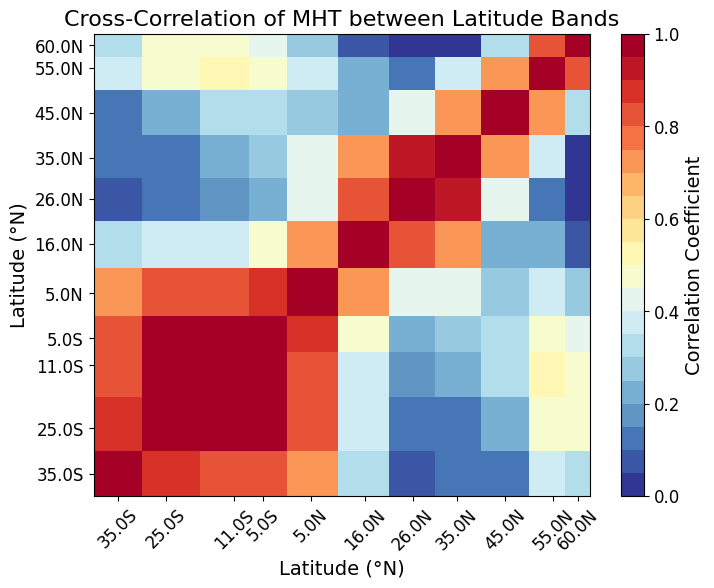

In [ ]:
cmap = plt.get_cmap("RdYlBu_r")
# cmap = plt.get_cmap("viridis")
# cmap = plt.cm.bwr
colors = cmap(np.linspace(0, 1, 20))
sliced_cmap = mcolors.ListedColormap(colors)


plot_crosscorr(ds, lats, lat_labels, cmap=sliced_cmap, savefig=True)

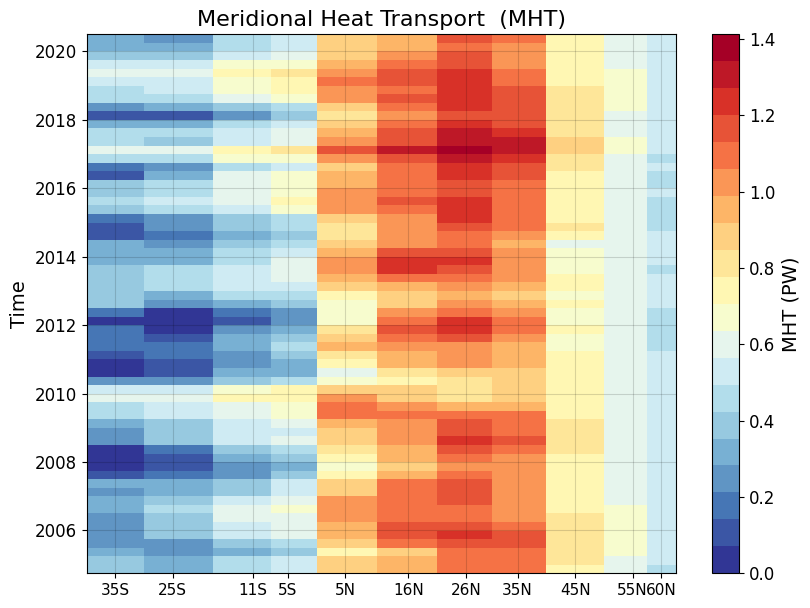

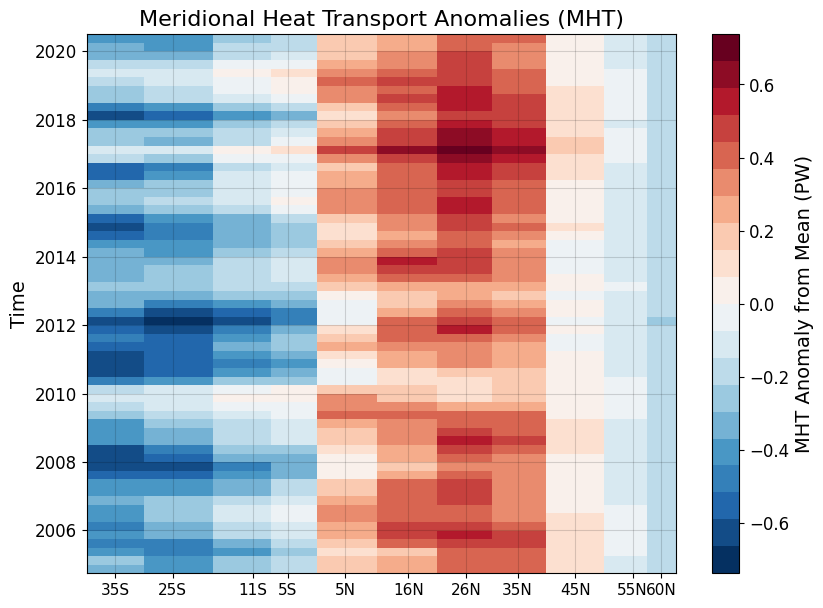

In [ ]:
plot_hovmöller(ds, lats, cmap=sliced_cmap, savefig=False, anomalies=False)

cmap = plt.cm.RdBu_r
colors = cmap(np.linspace(0, 1, 20))
sliced_cmap = mcolors.ListedColormap(colors)

plot_hovmöller(ds, lats, cmap=sliced_cmap, savefig=False, anomalies=True)

In [ ]:
# array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])
ref_lat = 35                   
nlags   = 12                        

lats      = MHT_dict["lats"]



/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1472/686076830.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend()


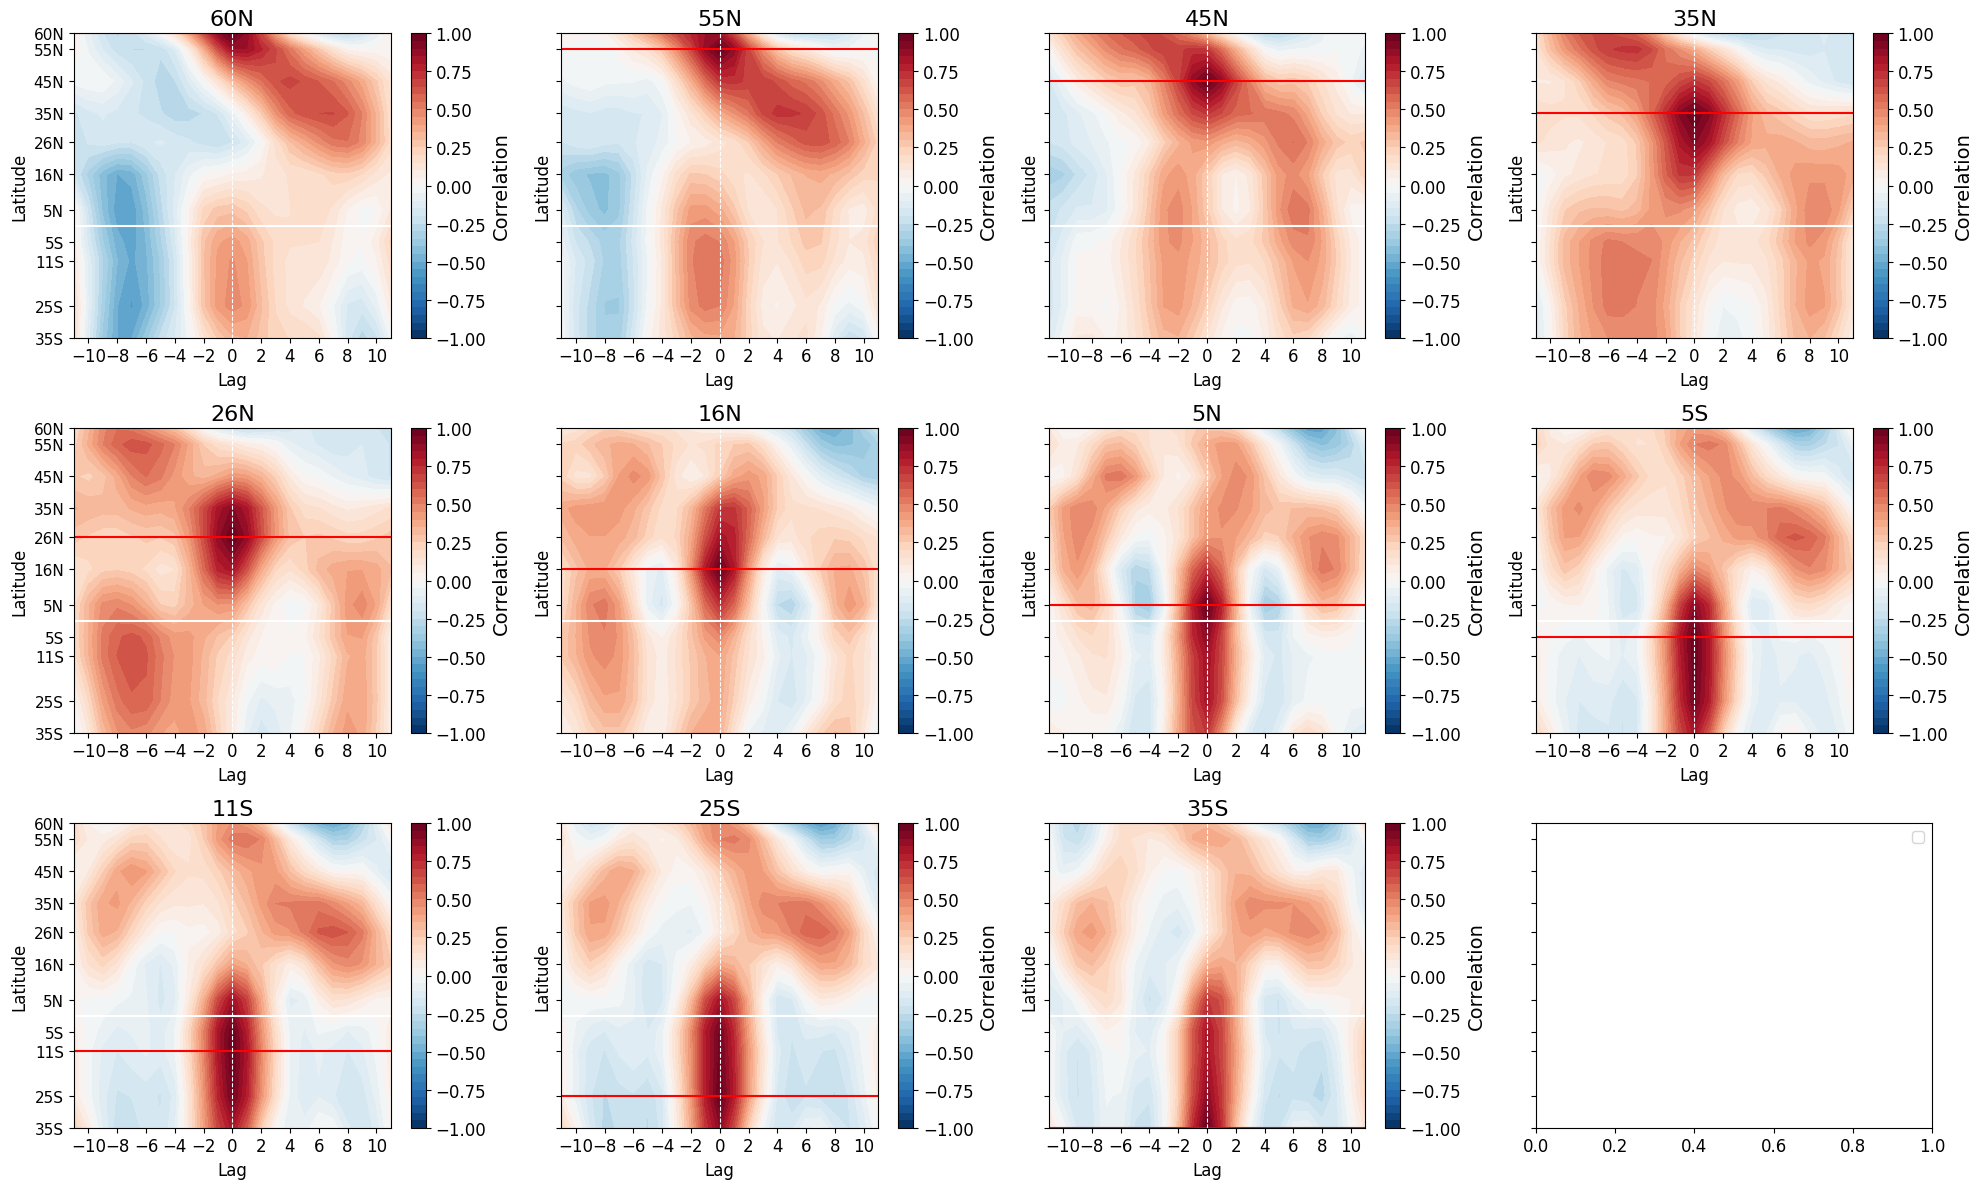

In [ ]:

cmap = plt.cm.RdBu_r
all_lags = np.arange(-(nlags-1), nlags)

corr_matrix = np.full((len(lats), len(all_lags)), np.nan)

ref_lats = lats

ytick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
ytick_labels = ["35S","25S","11S","5S","5N","16N","26N","35N","45N","55N","60N"]
   
   
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes = axes.flatten() 

MHT_mean = ds

for ax, ref_lat in zip(axes, ref_lats):
    ref_idx = np.argmin(np.abs(lats - ref_lat))
    ts_ref  = MHT_mean.isel(lat=ref_idx).values

    corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
    for i, lat in enumerate(lats):
        ts = MHT_mean.isel(lat=i).values
        pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
        neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
        full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
        corr_matrix[i, :] = full_corr

    # --- Plot ---
    cf = ax.contourf(
        all_lags, lats, corr_matrix,
        levels=np.linspace(-1, 1, 41),
        cmap=cmap,
    )
    plt.colorbar(cf, ax=ax, label='Correlation')

    ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
    ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
    ax.axhline(0, color='white', linewidth=1.5)

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels, fontsize=11)
    ax.set_xticks(np.arange(all_lags[1], all_lags[-1] + 1, 2))

    ref_label = f"{abs(ref_lat):.0f}{'N' if ref_lat >= 0 else 'S'}"
    ax.set_xlabel(f'Lag', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'{ref_label}')
    
axes[-1].legend()

plt.tight_layout()
# plt.savefig(f'figures/lag_corr_ref{ref_lat}N.png', dpi=300, bbox_inches='tight')
plt.show()

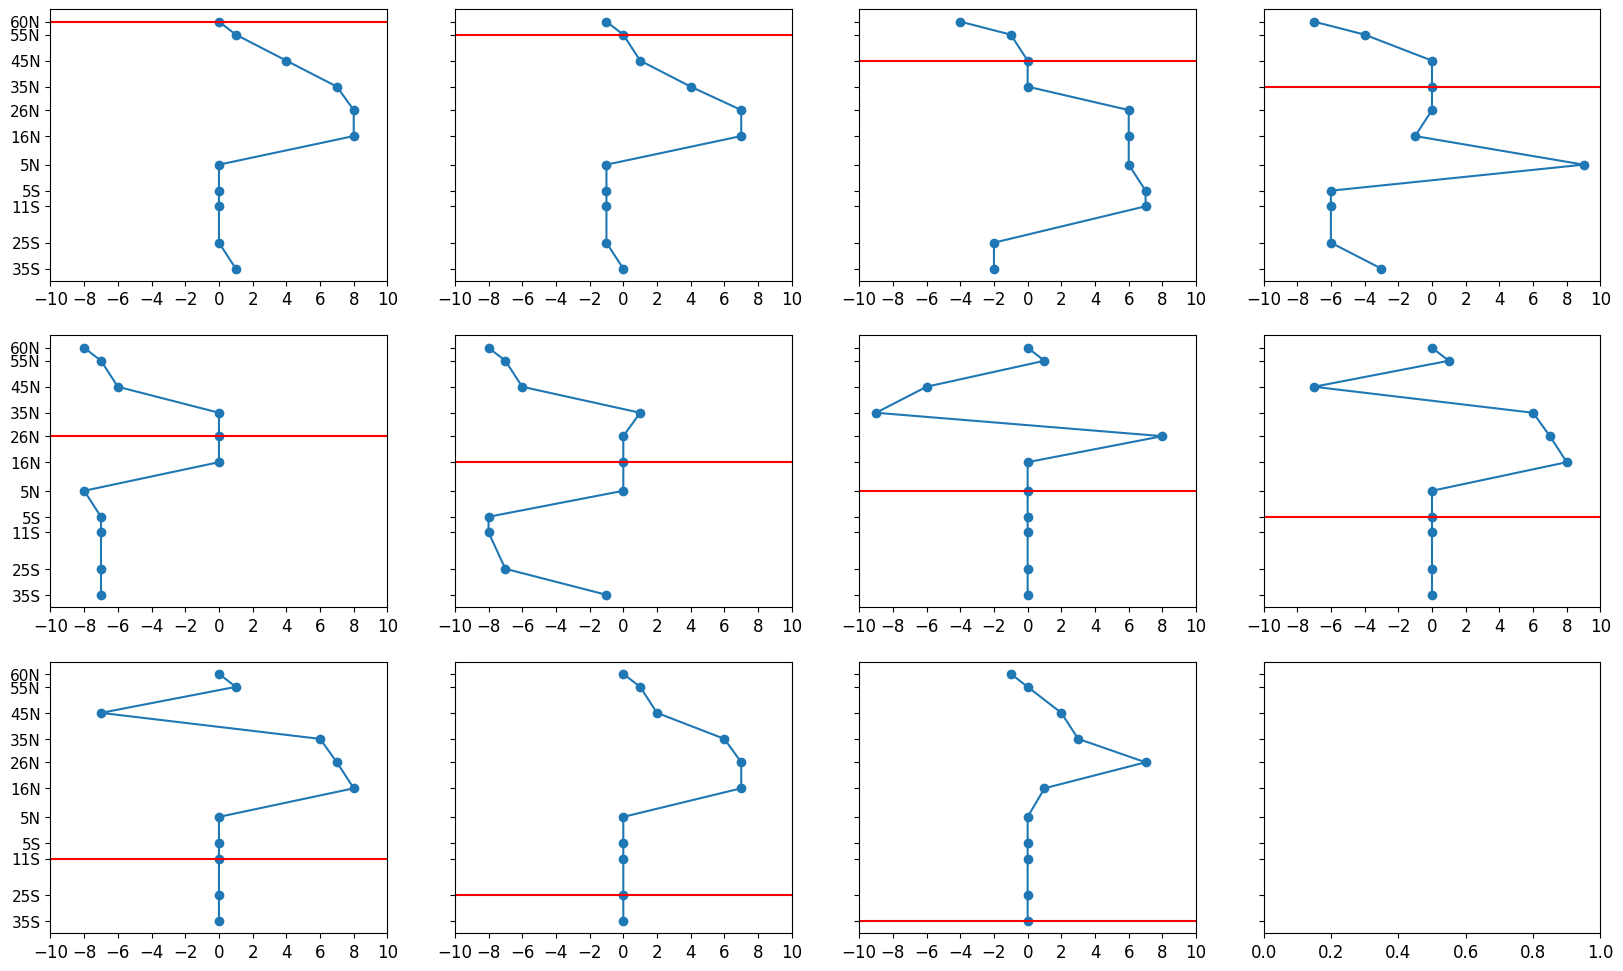

In [ ]:
# corr_matrix = np.full((len(lats), len(all_lags)), np.nan)

   
# fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
# axes = axes.flatten() 
# for ax, ref_lat in zip(axes, ref_lats):
#     ref_idx = np.argmin(np.abs(lats - ref_lat))
#     ts_ref  = MHT_mean.isel(lat=ref_idx).values

#     corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
#     for i, lat in enumerate(lats):
#         ts = MHT_mean.isel(lat=i).values
#         pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
#         neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
#         full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
#         corr_matrix[i, :] = full_corr


#     peak_lags = np.argmax(corr_matrix, axis=1)           # index of max correlation
#     peak_lags = all_lags[peak_lags]                       # convert to actual lag values
#     peak_corr = np.max(corr_matrix, axis=1)               # correlation at peak lag

#     # plot propagation speed
#     ax.plot(peak_lags, lats, marker="o")
    
#     ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
  
#     ax.set_yticks(ytick_pos)
#     ax.set_yticklabels(ytick_labels, fontsize=11)
#     ax.set_xticks(np.arange(all_lags[1], all_lags[-1] + 1, 2))

    
    